In [12]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Mount your Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define the base path to your dataset
base_dataset_path = '/content/drive/My Drive/PlantDoc-Dataset' # Adjust this path if necessary

# Define paths to the actual training and testing directories
train_data_path = f'{base_dataset_path}/train'
test_data_path = f'{base_dataset_path}/test'


# Load the training dataset and create a validation split from it
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_data_path, # Pointing to the 'train' subdirectory
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_data_path, # Pointing to the 'train' subdirectory for validation split
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load the test dataset
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_data_path, # Pointing to the 'test' subdirectory
    seed=123, # Using a seed for reproducibility
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)


class_names = train_dataset.class_names
print(class_names)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 2316 files belonging to 27 classes.
Using 1853 files for training.
Found 2316 files belonging to 27 classes.
Using 463 files for validation.
Found 236 files belonging to 27 classes.
['Apple Scab Leaf', 'Apple leaf', 'Apple rust leaf', 'Bell_pepper leaf', 'Bell_pepper leaf spot', 'Blueberry leaf', 'Cherry leaf', 'Corn Gray leaf spot', 'Corn leaf blight', 'Corn rust leaf', 'Peach leaf', 'Potato leaf early blight', 'Potato leaf late blight', 'Raspberry leaf', 'Soyabean leaf', 'Squash Powdery mildew leaf', 'Strawberry leaf', 'Tomato Early blight leaf', 'Tomato Septoria leaf spot', 'Tomato leaf', 'Tomato leaf bacterial spot', 'Tomato leaf late blight', 'Tomato leaf mosaic virus', 'Tomato leaf yellow virus', 'Tomato mold leaf', 'grape leaf', 'grape leaf black rot']


In [13]:
# Load the pre-trained ResNet50V2 model
base_model = ResNet50V2(weights='imagenet', include_top=False)

# Freeze the base model
base_model.trainable = False

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(len(class_names), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [15]:
# Train the model
epochs = 20
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=epochs
)

Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 396s 7s/step - accuracy: 0.0807 - loss: 137.4028 - val_accuracy: 0.1015 - val_loss: 19.9833
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 385s 7s/step - accuracy: 0.1079 - loss: 14.0884 - val_accuracy: 0.0713 - val_loss: 11.1009
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 387s 7s/step - accuracy: 0.0913 - loss: 8.7543 - val_accuracy: 0.0821 - val_loss: 6.5398
Epoch 4/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 448s 7s/step - accuracy: 0.1279 - loss: 5.7318 - val_accuracy: 0.0864 - val_loss: 5.2504
Epoch 5/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 437s 7s/step - accuracy: 0.1349 - loss: 4.3040 - val_accuracy: 0.0886 - val_loss: 3.2718
Epoch 6/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 403s 7s/step - accuracy: 0.1161 - loss: 3.1903 - val_accuracy: 0.0734 - val_loss: 3.2547
Epoch 7/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 434s 7s/step - accuracy: 0.0887 - loss: 3.2167 - val_accuracy: 0.0756 - val_loss: 3.2714
Epoch 8/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 403s 7s/step - accuracy: 0.1192 - loss: 3.1972 - val_accuracy: 0.088

In [16]:
# Define the path to your dataset (assuming it's the same as the training/validation data)
# dataset_path is already defined in a previous cell

# Create the test dataset (using validation subset, as the split was 80/20)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation", # Use the validation subset for testing
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Note: In a real-world scenario, it's better to have a separate test set that was not used during training or validation.
# However, based on the previous code creating train and validation sets from a 20% split,
# we'll use the validation subset as the test set here for demonstration purposes.

Found 2552 files belonging to 2 classes.
Using 510 files for validation.


In [17]:
# Step 1: Evaluate the model on the test set to get loss and accuracy
print("Evaluating the model on the test dataset...")
loss, accuracy = model.evaluate(test_dataset)

print("\n-----------------------------------------")
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Test Loss: {loss:.4f}")
print("-----------------------------------------")


# Step 2: Get predictions to be used for detailed metrics
print("\nGenerating predictions on the test dataset...")
y_pred_probs = []
y_true = []

# Iterate over the test dataset to get true labels and predictions
for image_batch, label_batch in test_dataset:
    # Append the true labels
    y_true.extend(label_batch.numpy())

    # Get model predictions (probabilities)
    preds = model.predict(image_batch, verbose=0)

    # Append the predicted labels (the index of the highest probability)
    y_pred_probs.extend(np.argmax(preds, axis=-1))

print("Predictions generated successfully.")

Evaluating the model on the test dataset...
16/16 ━━━━━━━━━━━━━━━━━━━━ 85s 5s/step - accuracy: 0.0000e+00 - loss: 3.6217

-----------------------------------------
Test Accuracy: 0.00%
Test Loss: 3.6614
-----------------------------------------

Generating predictions on the test dataset...
Predictions generated successfully.



Classification Report:
                 precision    recall  f1-score   support

Apple Scab Leaf       0.00      0.00      0.00      48.0
     Apple leaf       0.00      0.00      0.00     462.0

      micro avg       0.00      0.00      0.00     510.0
      macro avg       0.00      0.00      0.00     510.0
   weighted avg       0.00      0.00      0.00     510.0


Generating Confusion Matrix...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

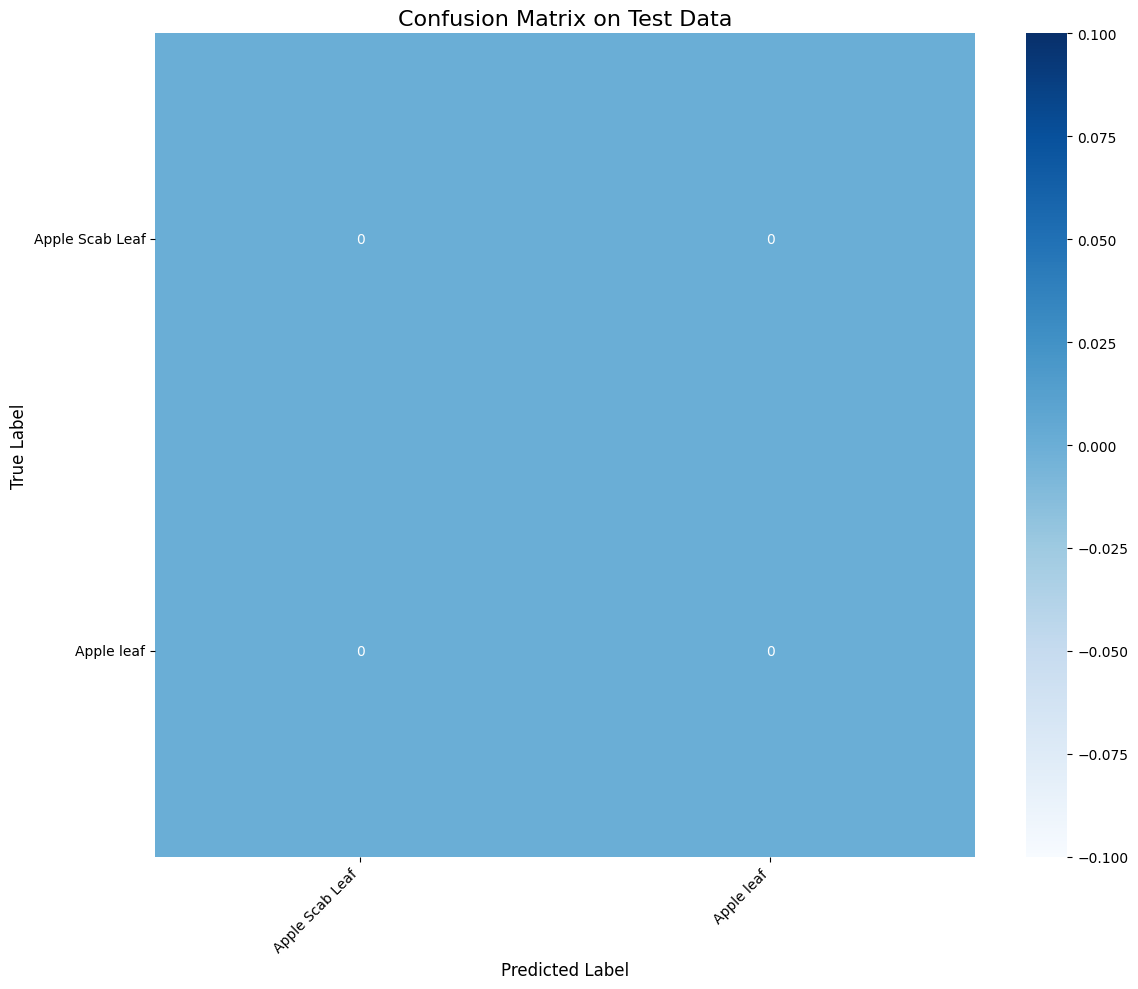


Visualizing F1-Score for each class...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

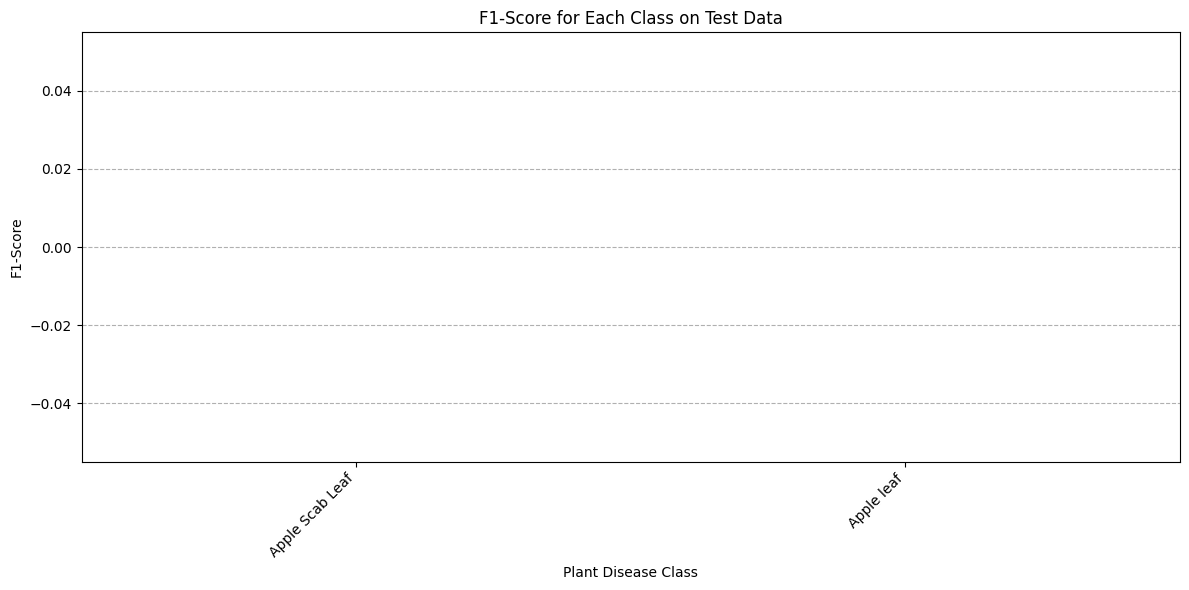

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np # Import numpy

# For clarity, let's rename y_pred_probs to y_pred since it contains the final predicted labels
y_pred = y_pred_probs

# You will need the 'class_names' list that was created when you first loaded the dataset
# If you don't have it available, you can get it from the training dataset like this:
# class_names = train_dataset.class_names

# Get the unique labels present in the test dataset
unique_labels = np.unique(y_true)

# Filter class_names to include only the labels present in the test dataset
test_class_names = [class_names[i] for i in unique_labels]


# --- Step 3: Display the Classification Report ---
# This report provides key metrics like precision, recall, and F1-score for each class.
print("\nClassification Report:")
# Provide the unique labels present in the test set to classification_report
print(classification_report(y_true, y_pred, target_names=test_class_names, labels=unique_labels))


# --- Step 4: Visualize the Confusion Matrix ---
# The confusion matrix helps you see exactly which classes the model is confusing.
print("\nGenerating Confusion Matrix...")
# Use the unique labels and filtered class names for the confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=unique_labels)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_class_names, yticklabels=test_class_names)
plt.title('Confusion Matrix on Test Data', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()


# --- Step 5: Visualize Per-Class F1-Scores ---
# This bar chart makes it easy to compare the model's performance on each specific class.
print("\nVisualizing F1-Score for each class...")
# Create a dictionary from the classification report using the unique labels
report_dict = classification_report(y_true, y_pred, target_names=test_class_names, labels=unique_labels, output_dict=True)

# Convert to a pandas DataFrame
report_df = pd.DataFrame(report_dict).transpose()

# Filter out the summary rows to only plot the classes that are in test_class_names
class_report_df = report_df.loc[test_class_names]

# Plot the F1-scores
plt.figure(figsize=(12, 6))
class_report_df['f1-score'].plot(kind='bar', colormap='viridis')
plt.title('F1-Score for Each Class on Test Data')
plt.xlabel('Plant Disease Class')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()